# 08 The decision layer

**Purpose:** turn the model outputs from notebooks 05 to 07 into what each person at Waypoint actually needs to act on. The dispatcher, loaders, drivers and store managers are not data people. A late probability of 0.63 or a forecast error of 7% means nothing to a driver at 3 AM.

**Rules every output follows:**
- **Clock times, not probabilities.** "Arrives 06:10 to 06:40", not "P(late) = 0.31".
- **Ranges, not single numbers**, so nobody is misled by false precision.
- **A traffic light always comes with an action.**
- **One reason line**, taken from the features that pushed the risk up the most.

**Who gets what:**

| Role | When | Output | Section |
|---|---|---|---|
| Dispatcher | after the 4 PM cutoff | risk board: every route with red, amber and green stops, a reason and a suggested fix | 2 |
| Driver | before leaving the depot | run sheet: windows, arrival ranges, unloading minutes, risky stops | 3 |
| Store manager | the evening before | a short message with the arrival range | 3, 4 |
| Dispatcher | on a peak day | deferral list with reasons, and a notice for each store | 4 |
| Loader | before loading | load order per trip, chilled section, how full the vehicle is | 4 |
| Fleet manager | weekly | reefer outlook for the next 10 weeks, and when to book reefer maintenance | 5 |

**Inputs:** the saved Task 1 models, the Task 1 and 2A predictions, and the Task 2B plan from notebook 07.

**Outputs:** sample sheets and messages in `reports/decision_layer/`, ready to show the people who would use them.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xora import allocation as al
from xora import decisions as dl
from xora import features as fe
from xora.io import load_processed, load_raw
from xora.paths import MODELS, REPORTS, SUBMISSIONS
from xora.plotting import apply_style, SERIES, INK, INK_SOFT

apply_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 110)

OUT = REPORTS / "decision_layer"
OUT.mkdir(parents=True, exist_ok=True)
LIGHTS = {"red": "#f6d5cf", "amber": "#fbe8c0", "green": "#d6efe2"}

def paint(df, col="light"):
    return df.style.apply(lambda r: [f"background-color: {LIGHTS.get(r[col], '')}"] * len(r), axis=1).hide(axis="index")

## 1. Rebuild the Task 1 view of the test period

The saved models are reloaded exactly as the final notebook will reload them. The route simulator gives each stop an arrival range (the middle and the slow end of 1,000 replays), the submission gives the late risk, and the challenger classifier splits each stop's risk into one contribution per feature, which becomes the reason line.

**Thresholds.** Notebook 05 showed the late-risk blend is calibrated on the holdout: across risk bands, the share of stops that ran late matched the predicted risk. So the lights can be set in plain terms:
- **red** at 50% or more: at least half of stops like this run late
- **amber** from 25%: about one in three or four
- **green** below 25%

In [2]:
stops = load_processed("stops")
tables = dict(outlets=load_processed("outlets"), vehicles=load_processed("vehicles"),
              allowance=load_processed("service_allowance"), calendar=load_processed("calendar"),
              road=load_processed("road_conditions"), traffic=load_processed("traffic_speed"))
full = fe.model_frame(stops, fe.build_task1_features(stops, **tables))
test = full[full.split == "test"]

simulator = joblib.load(MODELS / "route_simulator.pkl")
classifier = joblib.load(MODELS / "late_classifier.pkl")
task1 = pd.read_csv(SUBMISSIONS / "submission_task1.csv")

bands = simulator.simulate(test)[["delivery_id", "arrival_p50_min", "arrival_p90_min"]]
test = test.merge(task1, on="delivery_id").merge(bands, on="delivery_id")
feats = classifier.feature_name_
contrib = pd.DataFrame(classifier.booster_.predict(test[feats], pred_contrib=True)[:, :-1], columns=feats, index=test.index)

test["light"] = test.pred_late_prob.map(dl.light)
test["reason"] = [dl.reason_line(test.loc[i], contrib.loc[i]) if test.at[i, "light"] != "green" else ""
                  for i in test.index]
test["arrives"] = [dl.arrival_range(a, b) for a, b in zip(test.arrival_p50_min, test.arrival_p90_min)]

share = test.light.value_counts().reindex(["green", "amber", "red"])
pd.DataFrame({"stops": share, "share": (share / len(test) * 100).round(1).astype(str) + "%",
              "expected late": test.groupby("light").pred_late_prob.sum().reindex(share.index).round(0)})

,stops,share,expected late
light,,,
green,3658,73.0%,96.0
amber,307,6.1%,108.0
red,1049,20.9%,899.0


Across the six test weeks about one stop in five is red, and the red stops carry most of the expected late arrivals. That is the point of the board: the dispatcher looks at a fifth of the stops and finds most of the trouble.

## 2. Dispatcher: the risk board

The board is built at the 4 PM cutoff for the next day's draft routes. We show the riskiest test day, 7 March 2026, a monsoon Saturday.

One row per route, worst first, with a suggested fix that depends on where the red stops sit:
- red from the first stop: the whole route starts behind, so **leave earlier**
- red only further down: **split the route** before the first red stop, or move those stops to the front

In [3]:
DAY = test.groupby("date").pred_late_prob.mean().idxmax()
day = test[test.date == DAY].sort_values(["route_id", "seq"])

board = []
for rid, g in day.groupby("route_id"):
    worst = g.loc[g.pred_late_prob.idxmax()]
    board.append({"route": rid, "depot": g.depot.iloc[0], "brand": g.brand.iloc[0], "district": g.district.iloc[0],
                  "stops": len(g), "red": int((g.light == "red").sum()), "amber": int((g.light == "amber").sum()),
                  "leaves": dl.clock(g.route_start_min.iloc[0]),
                  "worst stop": f"stop {int(worst.seq) + 1} ({worst.outlet_id})" if worst.light != "green" else "",
                  "why": worst.reason, "suggested fix": dl.route_fix(g)})
board = pd.DataFrame(board)
board["light"] = np.where(board.red > 0, "red", np.where(board.amber > 0, "amber", "green"))
board = board.sort_values(["red", "amber"], ascending=False)
board.to_csv(OUT / "dispatcher_risk_board.csv", index=False)
print(f"{DAY.date()}: {len(board)} routes, {(board.light == 'red').sum()} with at least one red stop")
paint(board.head(12))

2026-03-07: 36 routes, 25 with at least one red stop


route,depot,brand,district,stops,red,amber,leaves,worst stop,why,suggested fix,light
R025904,Peliyagoda,Fresh,Colombo,8,5,0,05:01,stop 7 (OUT011),about 87 min past the cut-off once usual traffic is counted; the plan leaves 13 min before the cut-off,"split the route after stop 3, or move the red stops to the front",red
R025878,Peliyagoda,Fresh,Kurunegala,4,4,0,02:00,stop 4 (OUT069),"road advisory for Kurunegala (46, 100 = clear); about 16 min past the cut-off once usual traffic is counted",leave earlier: the route is at risk from its first stop,red
R025895,Peliyagoda,Fresh,Kurunegala,4,4,0,03:34,stop 3 (OUT068),"road advisory for Kurunegala (46, 100 = clear); about 71 min past the cut-off once usual traffic is counted",leave earlier: the route is at risk from its first stop,red
R025874,Kandy,Fresh,Kandy,6,3,1,05:22,stop 6 (OUT081),"about 46 min past the cut-off once usual traffic is counted; road advisory for Kandy (59, 100 = clear)","split the route after stop 3, or move the red stops to the front",red
R025886,Peliyagoda,Fresh,Colombo,7,3,0,04:39,stop 7 (OUT014),about 57 min past the cut-off once usual traffic is counted; OUT014 is often slow to receive,"split the route after stop 4, or move the red stops to the front",red
R025888,Peliyagoda,Fresh,Colombo,3,3,0,06:40,stop 2 (OUT003),about 51 min past the cut-off once usual traffic is counted; planned to arrive after the cut-off,leave earlier: the route is at risk from its first stop,red
R025900,Kandy,Fresh,Kegalle,4,3,0,05:32,stop 4 (OUT119),about 101 min past the cut-off once usual traffic is counted; the plan leaves 5 min before the cut-off,"split the route after stop 1, or move the red stops to the front",red
R025901,Peliyagoda,Fresh,Gampaha,5,3,0,05:02,stop 5 (OUT031),"about 17 min past the cut-off once usual traffic is counted; road advisory for Gampaha (61, 100 = clear)","split the route after stop 2, or move the red stops to the front",red
R025897,Kandy,Fresh,Nuwara Eliya,5,2,1,03:23,stop 5 (OUT107),about 195 min past the cut-off once usual traffic is counted; OUT107 is often slow to receive,"split the route after stop 3, or move the red stops to the front",red
R025899,Peliyagoda,Fresh,Kalutara,7,2,1,03:43,stop 7 (OUT045),about 86 min past the cut-off once usual traffic is counted; OUT045 is often slow to receive,"split the route after stop 5, or move the red stops to the front",red


Each line is something the dispatcher can do before the trucks leave. Reading the reasons down the board, the same few causes come up again and again: a route that is already behind once the usual traffic is counted, and road advisories on the day. Those are exactly the drivers notebook 05 found.

## 3. Driver run sheet and store messages

The driver of the riskiest route gets a run sheet on their phone before leaving the depot, so it works without signal. Each store on the route gets a message the evening before.

In [4]:
ROUTE = board.route.iloc[0]
r = day[day.route_id == ROUTE].sort_values("seq")
run_sheet = pd.DataFrame({
    "stop": r.seq.astype(int) + 1, "outlet": r.outlet_id,
    "window": [f"{dl.clock(a)} to {dl.clock(b)}" for a, b in zip(r.window_open_time_min, r.window_close_time_min)],
    "planned": r.planned_arrival_min.map(dl.clock), "likely arrival": r.arrives,
    "unloading": [f"about {5 * max(1, round(m / 5))} min" for m in r.pred_service_min],
    "light": r.light,
    "note": np.where(r.light == "red", "likely late: call the store before you set off for it",
                     np.where(r.light == "amber", "call ahead if you are running behind", "")),
})
run_sheet.to_csv(OUT / f"driver_run_sheet_{ROUTE}.csv", index=False)
print(f"Route {ROUTE}, {r.brand.iloc[0]} {r.district.iloc[0]}, leaves the depot {dl.clock(r.route_start_min.iloc[0])}")
paint(run_sheet)

Route R025904, Fresh Colombo, leaves the depot 05:01


stop,outlet,window,planned,likely arrival,unloading,light,note
1,OUT008,05:00 to 07:30,05:26,06:00 to 06:15,about 10 min,green,
2,OUT010,05:00 to 07:30,05:48,06:25 to 06:45,about 20 min,green,
3,OUT013,05:00 to 07:30,06:12,07:15 to 07:40,about 15 min,green,
4,OUT005,04:00 to 07:45,06:36,08:00 to 08:30,about 20 min,red,likely late: call the store before you set off for it
5,OUT006,03:00 to 08:00,06:59,08:50 to 09:25,about 25 min,red,likely late: call the store before you set off for it
6,OUT007,05:30 to 08:00,07:23,09:40 to 10:20,about 30 min,red,likely late: call the store before you set off for it
7,OUT011,03:00 to 08:00,07:47,10:35 to 11:20,about 25 min,red,likely late: call the store before you set off for it
8,OUT012,05:30 to 08:00,08:10,11:25 to 12:15,about 20 min,red,likely late: call the store before you set off for it


In [5]:
messages = pd.DataFrame({"outlet": r.outlet_id, "light": r.light, "message": [dl.store_message(x) for x in r.itertuples()]})
messages.to_csv(OUT / f"store_messages_{ROUTE}.csv", index=False)
paint(messages)

outlet,light,message
OUT008,green,"Your Fresh delivery arrives 06:00 to 06:15, usually on time."
OUT010,green,"Your Fresh delivery arrives 06:25 to 06:45, usually on time."
OUT013,green,"Your Fresh delivery arrives 07:15 to 07:40, usually on time."
OUT005,red,"Your Fresh delivery is planned for 08:00 to 08:30. It may arrive after your 07:45 cut-off, so the driver will call you on the way. Please keep the receiving bay free."
OUT006,red,"Your Fresh delivery is planned for 08:50 to 09:25. It may arrive after your 08:00 cut-off, so the driver will call you on the way. Please keep the receiving bay free."
OUT007,red,"Your Fresh delivery is planned for 09:40 to 10:20. It may arrive after your 08:00 cut-off, so the driver will call you on the way. Please keep the receiving bay free."
OUT011,red,"Your Fresh delivery is planned for 10:35 to 11:20. It may arrive after your 08:00 cut-off, so the driver will call you on the way. Please keep the receiving bay free."
OUT012,red,"Your Fresh delivery is planned for 11:25 to 12:15. It may arrive after your 08:00 cut-off, so the driver will call you on the way. Please keep the receiving bay free."


The planned arrival times on this route are the ones Waypoint uses today. The likely arrival ranges are what the route simulation expects once depot delay, real drive times and real unloading times are counted. The gap between the two columns is the reason the route is red.

## 4. Peak day: deferrals, loading and early warnings

Notebook 07 planned scenario S1. Here the plan becomes four things people use:
- the dispatcher's deferral list, with a reason and a price for each deferred order
- a notice for every store whose order moves to tomorrow
- a loading sheet for every trip
- a warning for the stores the clock check found will be reached after opening

In [6]:
plan = load_processed("task2b_plan")
timeline = load_processed("task2b_timeline")
deferrals = load_processed("task2b_deferrals")
prob = al.load_problem(load_raw("task2b_peak_day_scenarios.csv"), load_raw("task2b_peak_day_fleet.csv"),
                       load_raw("vehicles.csv"), load_raw("district_travel.csv"), load_raw("service_allowance.csv"))
trips = al.trip_table(plan, prob)

d = deferrals.merge(plan[["order_ref", "order_volume_m3", "temp_requirement"]], on="order_ref", suffixes=("", "_plan"))
def why(x):
    if x.reason == "TOO_BIG_FOR_ANY_VEHICLE":
        return f"unavoidable: {x.order_volume_m3:.1f} m3 is bigger than the largest truck (38 m3); ask the store to split it"
    swap = f"serving it instead costs {-x.chilled_m3_change_if_served:.1f} m3 of other chilled goods"
    if x.chilled_stores_change_if_served > 0:
        swap += f", though it would reach {int(x.chilled_stores_change_if_served)} more store"
    return f"reefers full: {swap}"
deferral_list = pd.DataFrame({"order": d.order_ref, "outlet": d.outlet_id, "goods": d.brand + " " + d.temp,
                              "m3": d.m3.round(1), "days since served": d.days_since_served, "why": [why(x) for x in d.itertuples()],
                              "tomorrow": "priority 1"})
deferral_list.to_csv(OUT / "peak_day_deferral_list.csv", index=False)
deferral_list

,order,outlet,goods,m3,days since served,why,tomorrow
0,S1-021,OUT013,Fresh chilled,9.9,1,reefers full: serving it instead costs 0.2 m3 of other chilled goods,priority 1
1,S1-056,OUT053,Fresh chilled,3.8,2,reefers full: serving it instead costs 0.5 m3 of other chilled goods,priority 1
2,S1-071,OUT065,Fresh chilled,12.0,1,reefers full: serving it instead costs 1.0 m3 of other chilled goods,priority 1
3,S1-073,OUT066,Fresh chilled,5.8,1,reefers full: serving it instead costs 1.0 m3 of other chilled goods,priority 1
4,S1-075,OUT067,Fresh chilled,7.2,2,reefers full: serving it instead costs 1.0 m3 of other chilled goods,priority 1
5,S1-003,OUT002,Fresh chilled,1.8,1,"reefers full: serving it instead costs 1.6 m3 of other chilled goods, though it would reach 1 more store",priority 1
6,S1-005,OUT003,Fresh chilled,1.7,2,"reefers full: serving it instead costs 1.6 m3 of other chilled goods, though it would reach 1 more store",priority 1
7,S1-064,OUT060,Fresh chilled,6.8,1,reefers full: serving it instead costs 8.9 m3 of other chilled goods,priority 1
8,S1-078,OUT070,Style ambient,40.7,2,unavoidable: 40.7 m3 is bigger than the largest truck (38 m3); ask the store to split it,priority 1


In [7]:
notices = d.assign(order_volume_m3=d.m3)
notices = pd.DataFrame({"outlet": d.outlet_id, "message": [dl.deferral_message(x) for x in notices.itertuples()]})
notices.to_csv(OUT / "peak_day_store_notices.csv", index=False)
notices

,outlet,message
0,OUT013,Your chilled order (S1-021) moves to tomorrow because our refrigerated trucks are short today with several...
1,OUT053,Your chilled order (S1-056) moves to tomorrow because our refrigerated trucks are short today with several...
2,OUT065,Your chilled order (S1-071) moves to tomorrow because our refrigerated trucks are short today with several...
3,OUT066,Your chilled order (S1-073) moves to tomorrow because our refrigerated trucks are short today with several...
4,OUT067,Your chilled order (S1-075) moves to tomorrow because our refrigerated trucks are short today with several...
5,OUT002,Your chilled order (S1-003) moves to tomorrow because our refrigerated trucks are short today with several...
6,OUT003,Your chilled order (S1-005) moves to tomorrow because our refrigerated trucks are short today with several...
7,OUT060,Your chilled order (S1-064) moves to tomorrow because our refrigerated trucks are short today with several...
8,OUT070,Your Style order (S1-078) moves to tomorrow because at 40.7 m3 it is bigger than any single truck can carr...


The loading sheet lists each trip's orders in reverse stop order, so the first delivery is nearest the doors. Chilled orders are marked for the cold section, and any trip loaded to 90% or more of its volume or weight gets a reminder to count every case, because there is no room to fix a mistake once the doors close.

In [8]:
sheet = dl.loading_sheet(plan, timeline, trips)
sheet.to_csv(OUT / "peak_day_loading_sheets.csv", index=False)
FIRST_TRIP = trips.sort_values("volume_fill", ascending=False).iloc[0]
sheet[(sheet.vehicle_id == FIRST_TRIP.vehicle_id) & (sheet.trip_id == FIRST_TRIP.trip_id)]

,vehicle_id,trip_id,load_order,stop_no,order_ref,outlet_id,section,order_volume_m3,order_weight_kg,trip_fill,check
3,VEH006,1,1,4,S1-012,OUT007,chilled,11.722,1991.0,"32.8 of 33.4 m3, 5643 of 6840 kg",count every case before closing the doors
4,VEH006,1,2,3,S1-016,OUT009,chilled,6.944,1241.3,"32.8 of 33.4 m3, 5643 of 6840 kg",count every case before closing the doors
5,VEH006,1,3,2,S1-009,OUT005,chilled,10.090,1696.6,"32.8 of 33.4 m3, 5643 of 6840 kg",count every case before closing the doors
6,VEH006,1,4,1,S1-014,OUT008,chilled,4.003,713.9,"32.8 of 33.4 m3, 5643 of 6840 kg",count every case before closing the doors


In [9]:
late = timeline[timeline.late].merge(plan[["order_ref", "window_close_time"]], on="order_ref", suffixes=("", "_p"))
warnings = pd.DataFrame({
    "vehicle": late.vehicle_id, "trip": late.run, "outlet": late.outlet_id, "goods": late.brand + " " + late.temp_requirement,
    "arrives about": late.arrive, "cut-off": late.window_close_time,
    "message": [f"Tomorrow's {g} delivery comes on the truck's second run and should reach you around {a}, after your {c} cut-off. "
                f"Please have someone ready to receive it."
                for g, a, c in zip(late.brand + " " + late.temp_requirement, late.arrive, late.window_close_time)],
})
warnings.to_csv(OUT / "peak_day_late_warnings.csv", index=False)
warnings

,vehicle,trip,outlet,goods,arrives about,cut-off,message
0,VEH003,2,OUT074,Fresh chilled,08:16,08:00,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:16, after..."
1,VEH006,2,OUT029,Fresh chilled,08:14,08:00,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:14, after..."
2,VEH006,2,OUT028,Fresh chilled,08:38,08:00,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:38, after..."
3,VEH007,2,OUT054,Fresh chilled,08:57,07:30,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:57, after..."
4,VEH036,2,OUT062,Fresh chilled,08:27,08:00,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:27, after..."


## 5. Fleet manager: the weekly reefer outlook

The Task 2A forecast says how much chilled volume each depot will need each week. The fleet manager needs that in terms they can plan with: chilled volume per operating day, how many reefer trips that means at the depot's usual load, and how it compares with the busiest days the depot has actually handled in the route history.

The P90 forecast drives the decision, because running out of reefers costs far more than having one spare:
- **red** when the busy end of a day is above the depot's 95th percentile day: no reefer maintenance that week, and line up second trips or a hired reefer
- **amber** above the 90th percentile day: book maintenance in another week
- **green** otherwise: a good week for reefer maintenance

In [10]:
delivered = stops[stops.service_min.notna()]
daily_history = delivered.groupby(["depot", "date"]).apply(lambda g: pd.Series({
    "chilled_m3": g.loc[g.temp_requirement == "chilled", "order_volume_m3"].sum(),
    "reefer_trips": g.loc[g.vehicle_temp == "reefer", "route_id"].nunique()})).reset_index()

outlook = dl.reefer_outlook(load_processed("task2a_forecast"), tables["calendar"], daily_history)
outlook.to_csv(OUT / "weekly_reefer_outlook.csv", index=False)
show = outlook.assign(
    week=outlook.iso_week, light=outlook.status,
    **{"chilled m3 a day": [f"{a:.0f} to {b:.0f}" for a, b in zip(outlook.m3_per_day_p50, outlook.m3_per_day_p90)],
       "reefer trips a day": [f"{a:.0f} to {b:.0f}" for a, b in zip(outlook.trips_per_day_p50, outlook.trips_per_day_p90)],
       "busiest days so far": [f"{a:.0f} to {b:.0f}" for a, b in zip(outlook.busy_day_p90, outlook.busy_day_p95)]})
paint(show[["depot", "week", "operating_days", "chilled m3 a day", "reefer trips a day", "busiest days so far", "light", "advice"]])

depot,week,operating_days,chilled m3 a day,reefer trips a day,busiest days so far,light,advice
Kandy,14,6,34 to 35,7 to 8,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,15,6,43 to 44,9 to 9,37 to 40,red,"busier than 95% of days this depot has run: no reefer maintenance, line up second trips or a hired reefer"
Kandy,16,4,35 to 37,8 to 8,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,17,6,36 to 37,8 to 8,37 to 40,amber,busier than 9 days in 10: book reefer maintenance in another week
Kandy,18,5,40 to 42,9 to 9,37 to 40,red,"busier than 95% of days this depot has run: no reefer maintenance, line up second trips or a hired reefer"
Kandy,19,6,33 to 34,7 to 7,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,20,6,33 to 34,7 to 7,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,21,6,34 to 35,7 to 7,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,22,6,41 to 42,9 to 9,37 to 40,red,"busier than 95% of days this depot has run: no reefer maintenance, line up second trips or a hired reefer"
Kandy,23,6,32 to 33,7 to 7,37 to 40,green,a normal load: a good week for reefer maintenance


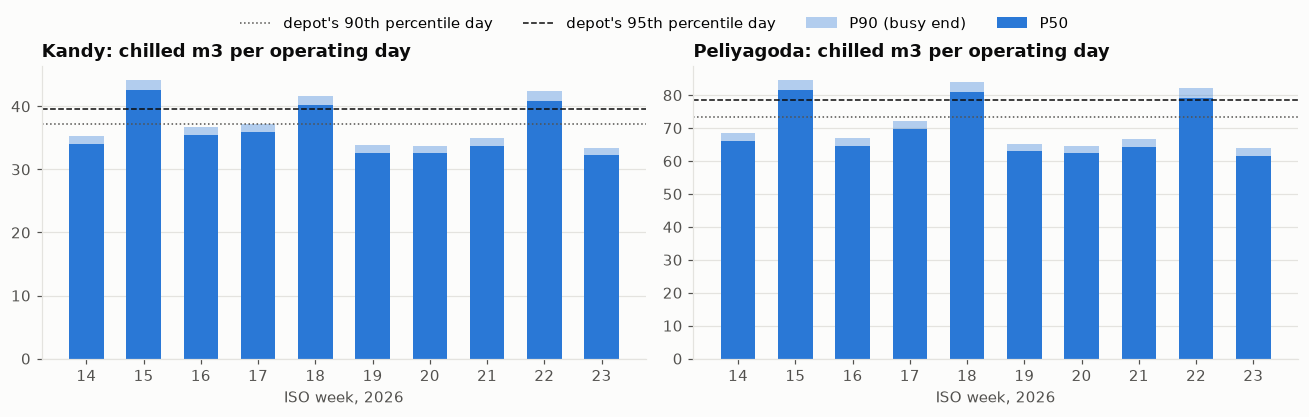

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (depot, g) in zip(axes, outlook.groupby("depot")):
    ax.bar(g.iso_week, g.m3_per_day_p90, color=SERIES[0], alpha=0.35, width=0.6, label="P90 (busy end)")
    ax.bar(g.iso_week, g.m3_per_day_p50, color=SERIES[0], width=0.6, label="P50")
    ax.axhline(g.busy_day_p90.iloc[0], color=INK_SOFT, linewidth=1, linestyle=":", label="depot's 90th percentile day")
    ax.axhline(g.busy_day_p95.iloc[0], color=INK, linewidth=1, linestyle="--", label="depot's 95th percentile day")
    ax.set_title(f"{depot}: chilled m3 per operating day")
    ax.set_xlabel("ISO week, 2026")
    ax.set_xticks(g.iso_week)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(); plt.show()

Three weeks stand out at both depots: week 15 before New Year, week 18 with Vesak and week 22 with Poson. In each, the busy end of a day is above all but the busiest 5% of days the depot has handled, so no reefer should go into the workshop then. The weeks around them, including the short festival week 16, carry normal loads and are the natural window for reefer maintenance. This is scenario S1 seen weeks ahead: a peak day with reefers in the workshop is exactly what notebook 07 had to plan around.

## Summary

- **Every model output now ends in an action.** Late risk becomes a red, amber or green light with a reason and a fix; arrival bands become clock ranges; the peak-day plan becomes loading sheets, deferral notices and early warnings; the demand forecast becomes a reefer maintenance calendar.
- **The thresholds mean something.** Because the late-risk blend is calibrated, red means at least half of such stops run late.
- **Reasons come from the model, in plain words.** Each red stop's reason line is built from the features that pushed its risk up the most.
- **All sample outputs are saved** in `reports/decision_layer/` as CSV files, ready for the dispatcher screen, loader tablets, driver phones and store messaging.

`Xora_FinalNotebook.ipynb` brings the whole pipeline together and ends by reloading the saved models.